## **Introduzione**

La seguente analisi è stata effettuata utilizzando un dataset che raccoglie i dati sui crimini registrati nella città di **Baltimora (Maryland, USA)** tra gli anni 2010 e 2017.
Il dataset contiene informazioni dettagliate su ogni evento criminale, tra cui **data, ora, tipologia di reato, localizzazione geografica, distretto di polizia e coordinate GPS**, coprendo un ampio periodo temporale.

L'obiettivo dell'analisi è quello di effettuare una clusterizzazione dei distretti di polizia basati sui loro profili di criminalità, utilizzando algoritmi di clustering come **K-Means**.

Per l'analisi verranno utilizzate librerie Python come **pandas, matplotlib, seaborn, numpy e sklearn**, che consentiranno di effettuare una **pulizia accurata dei dati, un'analisi esplorativa (EDA) e la modellazione del modello di clustering**.

**N.B.**: Per questioni di compatibilità con le versioni delle librerie, si consiglia di utilizzare la versione **3.12.4** di Python.

In [2]:
# Installazione dei pacchetti necessari
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import geopandas as gpd
import folium

### **Import del dataset**

Si inizia l'analisi importando il dataset in formato `.csv`, disponibile al seguente link ufficiale:
🔗 [City of Baltimore Crime Data](https://data.world/data-society/city-of-baltimore-crime-data)

Per avere una visualizzazione piu' dettagliata del dataset, si consiglia di visionare il file `timeseries.ipynb`, che contiene un'analisi piu' dettagliata delle feature del dataset.

### **Considerazioni preliminari**
Una prima analisi esplorativa (non mostrata qui) ha evidenziato la presenza di valori mancanti, colonne ridondanti e formati non uniformi (in particolare date, orari e coordinate geografiche).

**Caricamento e pulizia dei dati**
- Verranno rimosse le colonne non necessarie (`CrimeDate`, `Location`, `Neighborhood`, `Total Incidents`) e verranno rimosse righe con valori mancanti.
- La colonna `CrimeTime` (originariamente in formato H:M:S) verrà trasformata per estrarre solo l'ora. Quest'ultima verrà poi usata per creare una nuova colonna categorica, `HourBin`, che divide il giorno in quattro fasce: `Night`, `Morning`, `Afternoon` e `Evening`.
- Le coordinate di latitudine e longitudine verranno estratte dalla colonna `Location 1`, che verrà poi eliminata.
- I valori testuali nelle colonne `District` e `Description` verranno puliti, rimuovendo spazi e correggendo refusi.

In [4]:
# ------------------------------------------
# IMPORTAZIONE E PULIZIA DATI
# ------------------------------------------
# Lettura il dataset CSV
df = pd.read_csv("CrimeData.csv")

# Rimozione colonne non necessarie
df = df.drop(columns=['CrimeDate','Location', 'Neighborhood','Total Incidents'], axis=1)

# Conversione colonna "CrimeTime"
df['CrimeTime'] = pd.to_datetime(df['CrimeTime'], format='%H:%M:%S', errors='coerce').dt.hour

# Estrazione coordinate
df[['Latitude', 'Longitude']] = df['Location 1'].str.extract(r'\((.*), (.*)\)').astype(float)
df = df.drop(columns=['Location 1'])

# Uniformizzazione stringhe
df['Description'] = df['Description'].str.strip()
df['District'] = df['District'].str.strip().replace({
    'Central':'CENTRAL', 
    'NORTHESTERN':'NORTHEASTERN', 
    'SOUTHESTERN':'SOUTHEASTERN', 
    'Gay Street': 'EASTERN'
})
# Standardizzazione più chiara di Inside/Outside
io_map = {'I': 'Inside', 'Inside': 'Inside', 'O': 'Outside', 'Outside': 'Outside'}
df['Inside/Outside'] = df['Inside/Outside'].map(io_map)

# Creazione fasce orarie
bins  = [-0.1, 5, 11, 17, 23]
labs  = ['Night','Morning','Afternoon','Evening']
df['HourBin'] = pd.cut(df['CrimeTime'], bins=bins, labels=labs)

# Rimozione delle righe con valori nulli
df = df.dropna()

# Visualizzazione informazioni sul dataset dopo la pulizia
print("Totale righe dopo pulizia:", len(df))
df.head(10)

Totale righe dopo pulizia: 90865


,CrimeTime,CrimeCode,Description,Inside/Outside,Weapon,Post,District,Latitude,Longitude,HourBin
1,2.0,3CF,ROBBERY - COMMERCIAL,Inside,FIREARM,213.0,SOUTHEASTERN,39.28242,-76.59288,Night
5,3.0,4E,COMMON ASSAULT,Inside,HANDS,423.0,NORTHEASTERN,39.37070,-76.56709,Night
6,3.0,3CO,ROBBERY - COMMERCIAL,Outside,OTHER,933.0,SOUTHERN,39.28624,-76.64455,Night
9,8.0,4E,COMMON ASSAULT,Inside,HANDS,743.0,WESTERN,39.30340,-76.63842,Morning
11,9.0,4E,COMMON ASSAULT,Inside,HANDS,813.0,SOUTHWESTERN,39.30587,-76.67216,Morning
12,9.0,4E,COMMON ASSAULT,Inside,HANDS,312.0,EASTERN,39.29883,-76.61042,Morning
14,11.0,4E,COMMON ASSAULT,Inside,HANDS,444.0,NORTHEASTERN,39.32120,-76.53906,Morning
17,11.0,4B,AGG. ASSAULT,Outside,KNIFE,714.0,WESTERN,39.28810,-76.64888,Morning
19,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night
20,0.0,3AF,ROBBERY - STREET,Outside,FIREARM,733.0,WESTERN,39.31249,-76.64539,Night


### **Creazione dei Profili dei Distretti**
- Verranno creati dei profili per ogni distretto, applicando il One-Hot Encoding alle colonne `Description`, `Weapon`, `HourBin` e `Inside/Outside`, trasformandole in colonne binarie.
- Verranno poi raggruppati per `District` e calcolate la media di tutte le colonne binarie.

Il risultato sarà una nuova tabella dove ogni valore è una _percentuale_: ad esempio, la proporzione di crimini nel distretto "CENTRAL" che sono "COMMON ASSAULT" o che avvengono di "Night".

In [5]:
# Categorie per fare il profilo
cat_cols = ['Description','Weapon','HourBin', 'Inside/Outside']

# One-hot encoding (dummies)
dummies = pd.get_dummies(df[cat_cols], drop_first=False)

# Unità di aggregazione: District 
agg_df = pd.concat([df[['District']], dummies], axis=1) \
           .groupby('District', as_index=True).mean()

print("Shape profili distretti:", agg_df.shape)
agg_df.head(10)

Shape profili distretti: (9, 17)


,Description_AGG. ASSAULT,Description_COMMON ASSAULT,Description_RAPE,Description_ROBBERY - CARJACKING,Description_ROBBERY - COMMERCIAL,Description_ROBBERY - RESIDENCE,Description_ROBBERY - STREET,Weapon_FIREARM,Weapon_HANDS,Weapon_KNIFE,Weapon_OTHER,HourBin_Night,HourBin_Morning,HourBin_Afternoon,HourBin_Evening,Inside/Outside_Inside,Inside/Outside_Outside
District,,,,,,,,,,,,,,,,,
CENTRAL,0.259643,0.534182,0.018151,0.009470,0.028904,0.011147,0.138503,0.158528,0.572359,0.119463,0.149650,0.261221,0.136825,0.270100,0.331854,0.454474,0.545526
EASTERN,0.323434,0.546379,0.013934,0.007425,0.021766,0.009662,0.077400,0.158259,0.584215,0.114931,0.142596,0.211961,0.157140,0.288242,0.342657,0.539056,0.460944
NORTHEASTERN,0.274290,0.523088,0.015368,0.010998,0.037363,0.017698,0.121194,0.202185,0.565550,0.091988,0.140277,0.211945,0.149964,0.285943,0.352149,0.619374,0.380626
NORTHERN,0.272212,0.479088,0.018667,0.012760,0.049504,0.020085,0.147684,0.228852,0.519731,0.100425,0.150992,0.235113,0.142486,0.274102,0.348299,0.572543,0.427457
NORTHWESTERN,0.313379,0.455896,0.016667,0.017800,0.042290,0.015986,0.137982,0.243084,0.496372,0.103628,0.156916,0.199206,0.162245,0.281179,0.357370,0.556009,0.443991
SOUTHEASTERN,0.268477,0.540654,0.013201,0.007063,0.034810,0.011856,0.123938,0.157740,0.577062,0.115951,0.149247,0.289834,0.120659,0.232490,0.357017,0.500883,0.499117
SOUTHERN,0.316842,0.516364,0.016938,0.008325,0.030813,0.022871,0.087847,0.161722,0.565072,0.099426,0.173780,0.256459,0.134354,0.252057,0.357129,0.548900,0.451100
SOUTHWESTERN,0.335501,0.494385,0.016905,0.013595,0.028609,0.017969,0.093037,0.207117,0.537179,0.099184,0.156520,0.199669,0.157111,0.302045,0.341175,0.569334,0.430666
WESTERN,0.353855,0.505176,0.016079,0.012335,0.018502,0.011894,0.082159,0.172026,0.548128,0.108921,0.170925,0.194604,0.161123,0.306278,0.337996,0.536233,0.463767


## Fase 1 – Clustering dei distretti con K-Means

Dopo la costruzione dei profili percentuali di ciascun distretto, si passa alla fase di **clustering** con l’algoritmo **K-Means**, con l’obiettivo di individuare gruppi di distretti che presentano similitudini nei pattern di criminalità.

K-Means permette di suddividere i distretti in un numero prefissato di cluster 𝐾, minimizzando la distanza dei punti dai rispettivi centroidi.
In questa fase, vengono:

- Standardizzate le feature per rendere confrontabili le variabili (poiché K-Means si basa sulla distanza);

- Individuati i valori ottimali di 𝐾 tramite i metodi Elbow e Silhouette;

- Assegnati i distretti ai cluster ottenuti.

Questa prima analisi fornisce una base quantitativa su cui poggeranno le successive fasi esplorative e interpretative (PCA, heatmap, Lift, ecc.), che mirano a comprendere come e perché i distretti si raggruppano in certi modi.

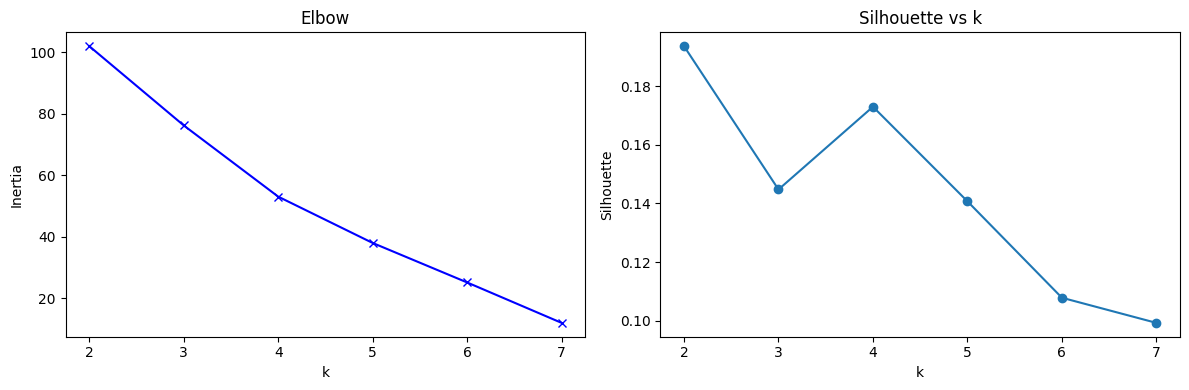

In [6]:
# Standardizzazione delle feature
X = agg_df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method per determinare il valore ottimale di k
distorsions = []
silhouettes = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, n_init='auto', random_state=0)
    km.fit(X_scaled)
    distorsions.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, distorsions, 'bx-')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow')

plt.subplot(1,2,2)
plt.plot(K, silhouettes, 'o-')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette vs k')
plt.tight_layout(); plt.show()

Dai grafici l'analisi stabilisce che `K=4` sia il valore ottimale di cluster.

L'algoritmo K-Means viene eseguito sui profili di distretto standardizzati, assegnando a ciascun distretto un'etichetta di cluster (0, 1, 2 o 3).

In [7]:
# === Fit finale di KMeans e assegnazione ai distretti ===
k_opt = 4 
kmeans = KMeans(n_clusters=k_opt, n_init='auto', random_state=0)
labels = kmeans.fit_predict(X_scaled)

# Assegnazione cluster ai distretti
clustered = agg_df.copy()
clustered['cluster'] = labels

# Conteggio dei distretti per ogni cluster
print(clustered['cluster'].value_counts().sort_index())
clustered.sort_values('cluster').head()

cluster
0    2
1    2
2    2
3    3
Name: count, dtype: int64


,Description_AGG. ASSAULT,Description_COMMON ASSAULT,Description_RAPE,Description_ROBBERY - CARJACKING,Description_ROBBERY - COMMERCIAL,Description_ROBBERY - RESIDENCE,Description_ROBBERY - STREET,Weapon_FIREARM,Weapon_HANDS,Weapon_KNIFE,Weapon_OTHER,HourBin_Night,HourBin_Morning,HourBin_Afternoon,HourBin_Evening,Inside/Outside_Inside,Inside/Outside_Outside,cluster
District,,,,,,,,,,,,,,,,,,
NORTHERN,0.272212,0.479088,0.018667,0.012760,0.049504,0.020085,0.147684,0.228852,0.519731,0.100425,0.150992,0.235113,0.142486,0.274102,0.348299,0.572543,0.427457,0
NORTHWESTERN,0.313379,0.455896,0.016667,0.017800,0.042290,0.015986,0.137982,0.243084,0.496372,0.103628,0.156916,0.199206,0.162245,0.281179,0.357370,0.556009,0.443991,0
CENTRAL,0.259643,0.534182,0.018151,0.009470,0.028904,0.011147,0.138503,0.158528,0.572359,0.119463,0.149650,0.261221,0.136825,0.270100,0.331854,0.454474,0.545526,1
SOUTHEASTERN,0.268477,0.540654,0.013201,0.007063,0.034810,0.011856,0.123938,0.157740,0.577062,0.115951,0.149247,0.289834,0.120659,0.232490,0.357017,0.500883,0.499117,1
NORTHEASTERN,0.274290,0.523088,0.015368,0.010998,0.037363,0.017698,0.121194,0.202185,0.565550,0.091988,0.140277,0.211945,0.149964,0.285943,0.352149,0.619374,0.380626,2


L’algoritmo K-Means ha suddiviso i distretti in `quattro gruppi` distinti e bilanciati.
Dopo l'esecuzione di K-Means, si possono visualizzare il numero dei distretti contenuti in ogni cluster e l'ordine dei distretti per ogni cluster.
- **Cluster 0**: contiene 2 distretti.
- **Cluster 1**: contiene 2 distretti.
- **Cluster 2**: contiene 3 distretti.
- **Cluster 3**: contiene 3 distretti.

Tuttavia, poiché K-Means assegna ogni osservazione a un cluster anche quando è un caso limite, non è in grado di identificare outlier o anomalie.

Prima di passare ad analisi più avanzate, si procede ora con una rappresentazione bidimensionale tramite `PCA` (***Principal Component Analysis***), utile per comprendere visivamente la separazione tra cluster.

## Fase 2 – Analisi visiva dei cluster tramite PCA

La **PCA** (Analisi delle Componenti Principali) viene utilizzata per ridurre la dimensionalità dei profili dei distretti, consentendo una rappresentazione visiva dei cluster individuati da K-Means.

Questa tecnica permette di:

- proiettare i dati in un piano bidimensionale mantenendo la massima varianza possibile;

- identificare le dimensioni latenti che spiegano la separazione tra i distretti;

- verificare visivamente la coerenza e separazione dei cluster ottenuti.

In questa fase, non si creano nuovi cluster ma si interpreta graficamente la struttura già calcolata da K-Means.

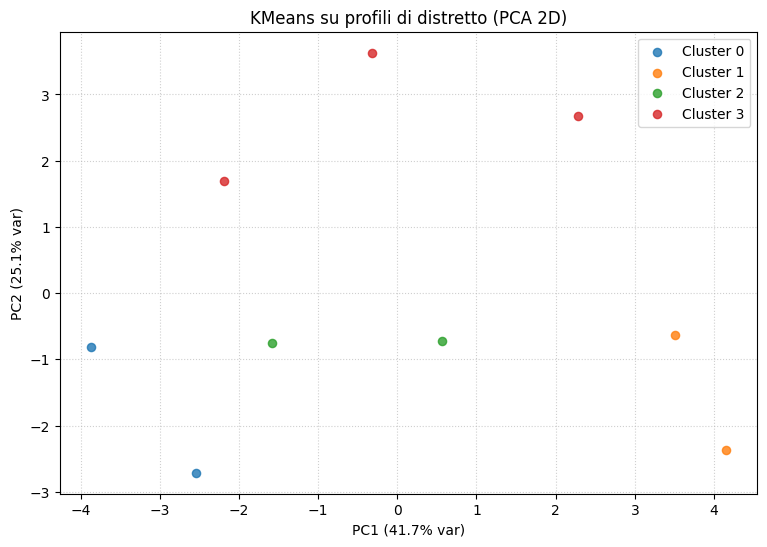

=== PC1 (41.7%) - Cosa sposta i punti a destra/sinistra? ===
--- Spingono a DESTRA (Valori Alti) ---
Description_COMMON ASSAULT    0.332926
Weapon_HANDS                  0.322216
Weapon_KNIFE                  0.294408
Inside/Outside_Outside        0.283471
HourBin_Night                 0.268611
Name: PC1, dtype: float64

--- Spingono a SINISTRA (Valori Bassi) ---
Weapon_FIREARM                     -0.342732
Description_ROBBERY - CARJACKING   -0.327928
Inside/Outside_Inside              -0.283471
HourBin_Morning                    -0.242137
Description_ROBBERY - RESIDENCE    -0.222155
Name: PC1, dtype: float64

=== PC2 (25.1%) - Cosa sposta i punti in alto/basso? ===
--- Spingono in ALTO (Valori Alti) ---
Description_AGG. ASSAULT    0.399974
HourBin_Afternoon           0.360607
HourBin_Morning             0.332476
Weapon_OTHER                0.122593
Weapon_HANDS                0.083462
Name: PC2, dtype: float64

--- Spingono in BASSO (Valori Bassi) ---
Description_ROBBERY - COMMERCIAL 

In [8]:
# === PCA per visualizzare in 2D ===
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9,6))
for c in np.unique(labels):
    plt.scatter(
        X_pca[labels == c, 0],
        X_pca[labels == c, 1],
        s=35,
        alpha=0.8,
        label=f'Cluster {c}')

plt.title('KMeans su profili di distretto (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Crea un DataFrame dei 'loadings' (pesi)
loadings = pd.DataFrame(
    pca.components_.T,  # .T per avere le feature come righe
    columns=['PC1', 'PC2'],
    index=agg_df.columns
)

# Stampa le feature più influenti per PC1 (Asse X)
print(f"=== PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) - Cosa sposta i punti a destra/sinistra? ===")
print("--- Spingono a DESTRA (Valori Alti) ---")
print(loadings['PC1'].sort_values(ascending=False).head(5))
print("\n--- Spingono a SINISTRA (Valori Bassi) ---")
print(loadings['PC1'].sort_values(ascending=True).head(5))

# Stampa le feature più influenti per PC2 (Asse Y)
print(f"\n=== PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) - Cosa sposta i punti in alto/basso? ===")
print("--- Spingono in ALTO (Valori Alti) ---")
print(loadings['PC2'].sort_values(ascending=False).head(5))
print("\n--- Spingono in BASSO (Valori Bassi) ---")
print(loadings['PC2'].sort_values(ascending=True).head(5))

Si nota chiaramente che i Cluster formano gruppi distinti, ben separati e significativi.

**Interpretazione PC1 e PC2**

L'asse X, che rappresenta PC1 (41.7% della Varianza), crea una separazione basata su **Gravità del Crimine e Luogo**.

- **Valori positivi (a destra)** dominati da: `Description_COMMON ASSAULT`, `Weapon_HANDS`, `Weapon_KNIFE`, `Inside/Outside_Outside` e `HourBin_Night`.
   - I distretti a destra del grafico, quindi, sono caratterizzati da **crimini meno gravi, commessi all'esterno, spesso di notte e senza armi da fuoco**.

- **Valori negativi (a sinistra)** dominati da: `Weapon_FIREARM`, `ROBBERY - CARJACKING`, `Inside/Outside_Inside` e `ROBBERY - RESIDENCE`.
   - I distretti a sinistra nel grafico sono caratterizzati da **crimini più gravi, con armi da fuoco, spesso legati a rapine e che avvengono all'interno**.

L'asse Y, che rappresenta PC1 (25.1% della Varianza), separa i distretti in base al **Tipo di Crimine e Orario**.

- **Valori positivo (in alto)** dominati da `Description_AGG. ASSAULT`, `HourBin_Afternoon` e `HourBin_Morning`.
   - I distretti in alto nel grafico hanno una maggior incidenza di **aggressioni (sia comuni che aggravate) che avvengono di giorno**.

- **Valori negativi (in basso)** dominati da: `ROBBERY - COMMERCIAL`, `ROBBERY - STREET`, `HourBin_Night` e `HourBin_Evening`.
   - I distretti in basso nel grafico hanno una maggiore incidenza di **rapine (commerciali e in strada) che avvengono di sera e di notte**.

## Fase 3 – Interpretazione dei centroidi

Una volta ottenuti i cluster, si analizzano i centroidi, ovvero i **profili medi** dei distretti appartenenti a ciascun gruppo.

L’obiettivo è comprendere quali caratteristiche definiscono ciascun cluster: quali tipologie di crimine, orari o contesti (“Inside/Outside”) sono predominanti.

Questo passo fornisce una prima interpretazione qualitativa, utile per delineare la “personalità” di ogni cluster prima di passare ad analisi più quantitative come il Lift.

In [9]:
# === Centroidi e feature più alte per cluster ===

# Centroidi nella scala standardizzata e riportati alle percentuali originali
centers_unscaled = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=agg_df.columns,
    index=[f'Cluster {i}' for i in range(k_opt)]
)

# Top feature (le più “alte”) per ogni cluster
for c in centers_unscaled.index:
    print(f'\n=== {c}: feature dominanti ===')
    print(centers_unscaled.loc[c]
        .sort_values(ascending=False)
        .head(10)
        .round(3))


=== Cluster 0: feature dominanti ===
Inside/Outside_Inside         0.564
Weapon_HANDS                  0.508
Description_COMMON ASSAULT    0.467
Inside/Outside_Outside        0.436
HourBin_Evening               0.353
Description_AGG. ASSAULT      0.293
HourBin_Afternoon             0.278
Weapon_FIREARM                0.236
HourBin_Night                 0.217
Weapon_OTHER                  0.154
Name: Cluster 0, dtype: float64

=== Cluster 1: feature dominanti ===
Weapon_HANDS                  0.575
Description_COMMON ASSAULT    0.537
Inside/Outside_Outside        0.522
Inside/Outside_Inside         0.478
HourBin_Evening               0.344
HourBin_Night                 0.276
Description_AGG. ASSAULT      0.264
HourBin_Afternoon             0.251
Weapon_FIREARM                0.158
Weapon_OTHER                  0.149
Name: Cluster 1, dtype: float64

=== Cluster 2: feature dominanti ===
Inside/Outside_Inside         0.584
Weapon_HANDS                  0.565
Description_COMMON ASSAULT    

L'output mostra la "personalità" di ogni cluster, elencando le 10 caratteristiche dominanti per ogni gruppo di distretti.

Si può notare come `Weapons_HANDS` e `Description_COMMON ASSAULT` appaiono come le prime feature dominanti per tutti i cluster. Ciò non significa che i cluster siano tutti uguali, ma che questi sono i tipi di crimine/arma più comuni in _tutta_ la città.

Inoltre, si può notare come nel Cluster 2 e 0 la feature dominante è `Inside/Outside_Inside`, suggerendo che la feature è stata molto significativa per la clusterizzazione.

## Fase 4 – Confronto visivo dei profili tramite Heatmap

Per confrontare in modo immediato i profili medi dei cluster, viene costruita una heatmap delle percentuali di ciascuna feature.

Il colore indica la frequenza relativa: le celle più chiare rappresentano feature più comuni.

Questa visualizzazione permette di:

- individuare le feature condivise da tutti i cluster (es. crimini più diffusi in tutta la città);

- riconoscere i tratti distintivi di ciascun gruppo (es. armi, orari, contesto interno/esterno);

- identificare le feature rare, presenti in misura minima su tutti i distretti.

L’analisi è di tipo visivo e qualitativo, e verrà successivamente approfondita in chiave numerica con il calcolo del Lift.

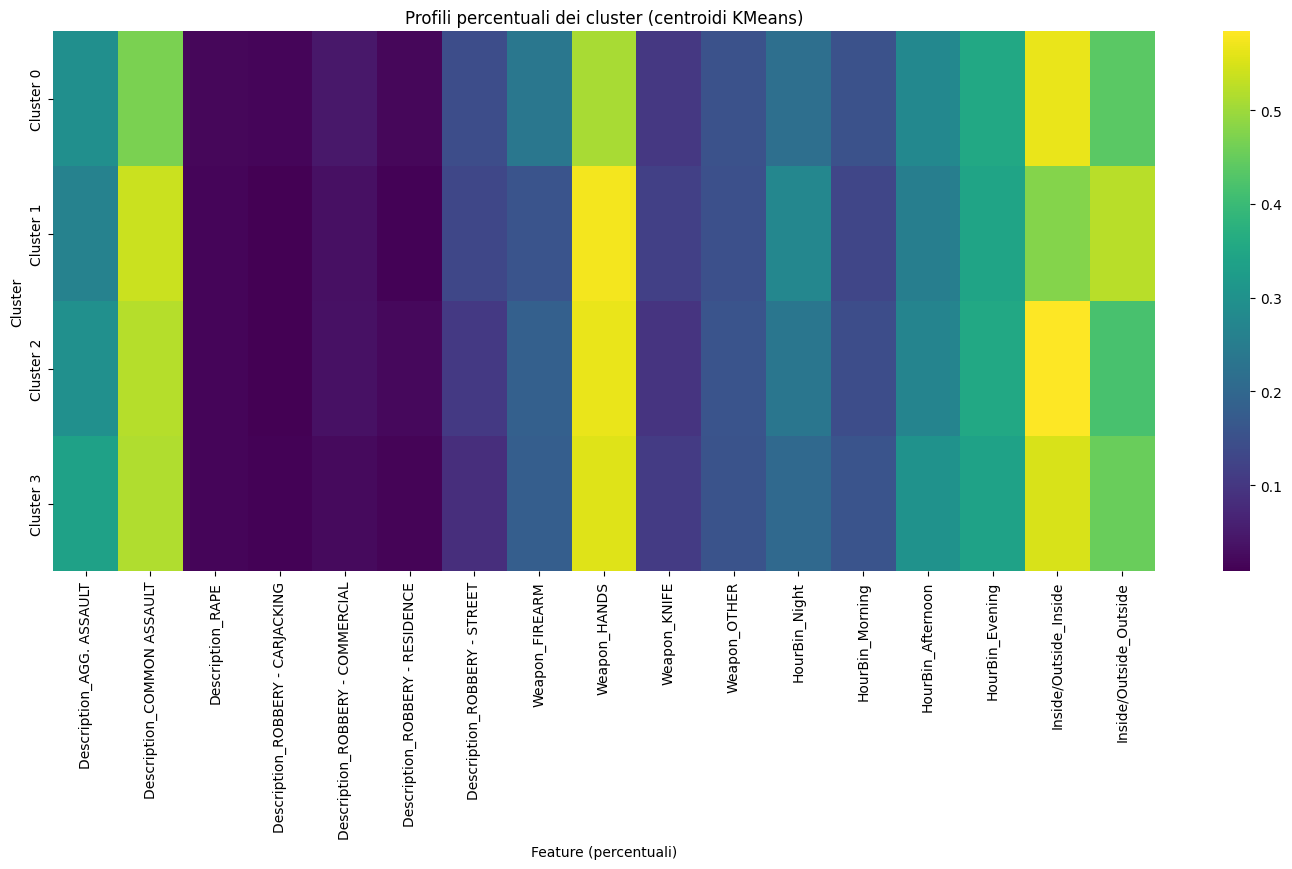

In [10]:
# === Heatmap dei centroidi per confronto rapido ===
plt.figure(figsize=(min(16, 0.5*len(agg_df.columns)+6), 1.2*k_opt+4))
sns.heatmap(
    centers_unscaled,
    cmap='viridis',
    annot=False,
    cbar=True
)
plt.title('Profili percentuali dei cluster (centroidi KMeans)')
plt.xlabel('Feature (percentuali)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

**1. Feature comuni a tutti**: come già visto in precedenza e come ci si aspettava, le colonne `Weapons_HANDS`, `Description_COMMON ASSAULT`,  `Inside/Outside_Inside` e `Inside/Outside_Outside` sono le più luminose (dal verde al giallo) su _tutte e 4 le righe_.

**2. Differenze tra i cluster**:
   - **Cluster 1**: ha la cella più a (giallo brillante) in assoluto per `Inside/Outside_Outside`, ed è anche la riga più luminosa per `HourBin_Night`. Questo cluster è chiaramente definito da crimini che avvengono **all'esterno e di notte**.
   - **Cluster 0**: è visibilmente più luminoso (giallo-verde) degli altri su `Weapons_FIREARM`. Questo cluster (che riguarda i distretti `NORTHWESTERN` e `NORTHERN`) ha un profilo unico con una percentuale significativamente più alta di crimini con **armi da fuoco**, che avvengono prevalentemente **all'esterno**.
   - **Cluster 3**: è la riga più luminosa (verde più brillante) sulla colonna `Description_AGG. ASSAULT`, descrivendo come è un cluster di crimini che avvengono **all'interno** e caratterizzato da **aggressioni aggravate**.
   - **Cluster 2** sembra un profilo medio o generico di crimini `Inside/Outside_Inside`. Ha alte percentuali di `COMMON ASSALUT` e `Weapon_HANDS`, ma senza i picchi distintivi visti nel Cluster 1 (all'esterno), Cluster 0 (armi da fuoco) o Cluster 3 (aggressioni aggravate).

**3. Feature rare ovunque**: molte colonne, come `Description_RAPE`, `Description_HOMICIDE`, `Description_ROBBERY - CARJACKING` e anche `Description_SHOOTING`, sono viola scuro per tutti i cluster, indicando che sono eventi rari (con percentuali basse) in tutti i distretti.

In [11]:
# === Mappatura distretto-cluster ===
distretto_cluster = clustered[['cluster']].reset_index().rename(columns={'index':'District'})
distretto_cluster = distretto_cluster.sort_values(['cluster','District'])
distretto_cluster.head(20)

,District,cluster
3,NORTHERN,0
4,NORTHWESTERN,0
0,CENTRAL,1
5,SOUTHEASTERN,1
2,NORTHEASTERN,2
6,SOUTHERN,2
1,EASTERN,3
7,SOUTHWESTERN,3
8,WESTERN,3


# Fase 5 – Analisi quantitativa tramite Lift

Dopo la fase esplorativa condotta con la heatmap, si passa ora a un’analisi più quantitativa e comparativa.

L’obiettivo è misurare, per ciascun cluster, **quanto ogni caratteristica è più o meno rappresentata** rispetto alla media generale del dataset.

Il Lift quantifica questa differenza, permettendo di:

- individuare le feature sovra-rappresentate (Lift > 1) o sotto-rappresentate (Lift < 1);

- cogliere variazioni locali che la heatmap non mostrava visivamente;

- attribuire una vera e propria “personalità statistica” ai cluster.

In sintesi, mentre la heatmap mostra quanto una feature è frequente, il Lift mostra quanto più del normale lo è in ciascun cluster.

In [12]:
# === LIFT rispetto alla media globale ===
global_mean = agg_df.mean()

lift = centers_unscaled.copy()
for col in lift.columns:
    baseline = global_mean[col] if global_mean[col] != 0 else 1e-9
    lift[col] = lift[col] / baseline  # >1 = sopra la media globale

for c in lift.index:
    print(f'\n=== {c}: feature con lift più alto ===')
    print(
        lift.loc[c]
        .sort_values(ascending=False)
        .head(10)
        .round(2))


=== Cluster 0: feature con lift più alto ===
Description_ROBBERY - COMMERCIAL    1.41
Description_ROBBERY - CARJACKING    1.38
Description_ROBBERY - STREET        1.27
Weapon_FIREARM                      1.26
Description_ROBBERY - RESIDENCE     1.17
Description_RAPE                    1.09
HourBin_Morning                     1.04
Inside/Outside_Inside               1.04
HourBin_Evening                     1.02
HourBin_Afternoon                   1.00
Name: Cluster 0, dtype: float64

=== Cluster 1: feature con lift più alto ===
HourBin_Night                       1.20
Description_ROBBERY - STREET        1.17
Inside/Outside_Outside              1.15
Weapon_KNIFE                        1.11
Description_COMMON ASSAULT          1.05
Weapon_HANDS                        1.04
HourBin_Evening                     0.99
Description_ROBBERY - COMMERCIAL    0.98
Weapon_OTHER                        0.97
Description_RAPE                    0.97
Name: Cluster 1, dtype: float64

=== Cluster 2: feature 

I valori di Lift mostrano, per ciascun cluster, le feature più rappresentative rispetto alla media generale:
- **Lift > 1**: la feature è **sovra-rappresentata**, ovvero più comune del normale.
- **Lift = 1**: la feature è in linea con la media.
- **Lift < 1**: la feature è **sotto-rappresentata** (meno comune).

**Cluster 0** (Distretti `NORTHERN` e `NORTHWESTERN`)
→ È il cluster delle rapine con armi da fuoco. Le caratteristiche distintive sono:
`ROBBERY - COMMERCIAL` (1.41× la media), `ROBBERY - CARJACKING` (1.38×), `ROBBERY - STREET` (1.27×) e `Weapon_FIREARM` (1.26×).
Questo cluster rappresenta aree dove i crimini violenti armati sono significativamente più frequenti rispetto alla media cittadina.

**Cluster 1** (Distretti `CENTRAL` e `SOUTHEASTERN`)
→ Cluster dei crimini notturni e all’esterno, con `HourBin_Night` (1.20×), `ROBBERY - STREET` (1.17×) e `Inside/Outside_Outside` (1.15×).
Anche le armi da taglio (`Weapon_KNIFE` 1.11×) risultano più presenti rispetto alla media.

**Cluster 2**(Distretti `NORTHEASTERN` e `SOUTHERN`)
→ Cluster delle rapine a proprietà e all’interno, definito da `ROBBERY - RESIDENCE` (1.31×) e `ROBBERY - COMMERCIAL` (1.05×).
Si tratta di aree dove prevalgono i reati di intrusione o a danno di esercizi, spesso in contesti interni.

**Cluster 3** (Distretti `EASTERN`, `SOUTHWESTERN` e `WESTERN`)
→ Cluster delle aggressioni diurne, con `AGG. ASSAULT` (1.12×), `HourBin_Afternoon` (1.08×) e `HourBin_Morning` (1.08×).
Indica una maggiore concentrazione di aggressioni fisiche durante le ore diurne rispetto alla media complessiva.

In sintesi, il confronto con la media generale tramite Lift conferma e raffina quanto osservato nella heatmap:

i **cluster 0 e 1** rappresentano contesti violenti o notturni, con un’elevata incidenza di armi o crimini all’esterno;

i **cluster 2 e 3** mostrano invece profili più legati all’interno o a situazioni di aggressione fisica, spesso in fasce orarie diurne o pomeridiane.

L’analisi del Lift si dimostra quindi un passaggio chiave per quantificare la rilevanza relativa delle feature nei vari cluster, permettendo di interpretare i risultati non solo in termini qualitativi (colore della heatmap) ma anche statistici (scostamento rispetto alla media).

## Fase 6 – Analisi gerarchica dei distretti

Per validare e approfondire i risultati del K-Means, si esegue ora un clustering gerarchico.

A differenza del K-Means, questa tecnica:

- non richiede di fissare a priori il numero di cluster;

- mostra progressivamente come i distretti si uniscono in base alla loro somiglianza;

- consente di visualizzare la forza dei legami tra i gruppi già identificati.

Il dendrogramma risultante fornisce una rappresentazione ad albero che evidenzia quali distretti sono più simili e in che ordine si aggregano, confermando (o ricalibrando) le conclusioni tratte dal K-Means.

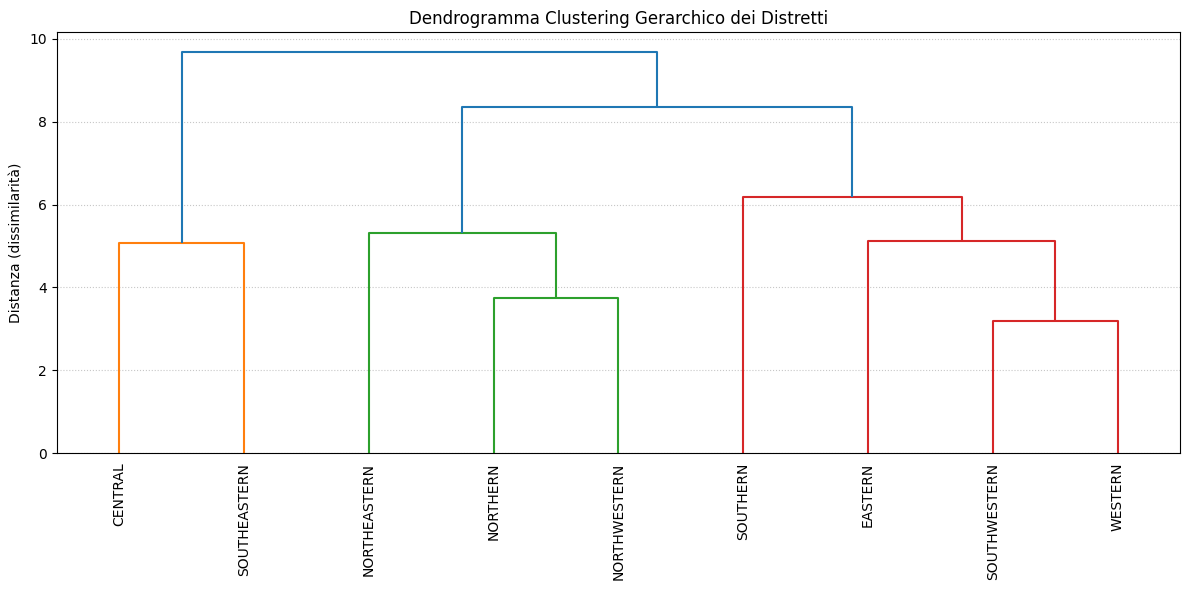

In [13]:
# Calcola il linkage usando 'ward' (minimizza la varianza, simile a K-Means)
# Usa gli stessi dati standardizzati (X_scaled) usati per K-Means
Z = linkage(X_scaled, method='ward')

# Plotta il dendrogramma
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    labels=agg_df.index,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('Dendrogramma Clustering Gerarchico dei Distretti')
plt.ylabel('Distanza (dissimilarità)')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Questo dendrogramma conferma i risultati K-Means e aggiunge un ulteriore livello di dettaglio, mostrando _come e quanto_ i distretti sono simili tra loro.

**1. Conferma del Cluster 3**: i distretti `SOUTHWESTERN` e `WESTERN` sono i primi in assoluto a fondersi (la linea rossa orizzontale che li unisce è la più bassa con distanza ~3.2). Ciò significa che sono la coppia di distretti con i profili di criminalità **più simili in assoluto** in tutta l'analisi. Questo conferma che il nucleo del K-Means Cluster 3 è un raggruppamento estremamente forte.

**2. Conferma del Cluster 0**: i distretti `NORTHERN` e `NORTHWESTERN` sono uniti dalla linea verde ad una distanza di ~3.8 ed è la seconda fusione più stretta, confermando che anch'essi sono un raggruppamento **molto logico e robusto**.

**3. Gli altri raggruppamenti**: per il Cluster 1 `CENTRAL` e `SOUTHEASTERN` (linea arancione) si fondono ad una distanza maggiore (~5.1). `EASTERN` si unisce al gruppo "rosso" (Cluster 3) a distanza ~5.1, mentre `NORTHEASTERN` si unisce al gruppo "verde" (Cluster 0) a distanza ~5.3.

**4. Il "Ponte" (Cluster 2)**: come nell'analisi K-Means, `NORTHEASTERN` e `SOUTHERN` **non si uniscono direttamente tra loro**. Il dendrogramma suggerisce che `NORTHEASTERN` ha più affinità con il Cluster 0 e `SOUTHERN` ha più affinità con il Cluster 3. Questo rafforza l'idea che il K-Means Cluster 2 sia il raggruppamento meno compatto, composto da distretti "ponte".

In conclusione, il dendrogramma arricchisce il K-Means, esplicitando come i Cluster 0,1 e 3 sono raggruppamento **molto naturali e robusti**. Al contrario, il Cluster 2 è il raggruppamento **più debole** ed ambiguo, composto da distretti ponte che hanno affinità anche con altri gruppi.

## Fase 7 – Visualizzazione geografica dei cluster

L’ultima fase dell’analisi integra i risultati del clustering con i dati geografici dei distretti di polizia, consentendo una lettura spaziale dei gruppi individuati.

Utilizzando la libreria Folium, viene generata una mappa interattiva che:

- mostra i distretti colorati in base al cluster di appartenenza;

- evidenzia la coerenza spaziale dei gruppi (ad es. distretti contigui nello stesso cluster);

- consente di verificare se esistono pattern territoriali coerenti con i risultati statistici.

Questa fase chiude il flusso dell’analisi, collegando i risultati numerici e visuali di K-Means con la realtà geografica della città.

In [ ]:
# Caricamento del file GeoJSON

gdf = gpd.read_file("Police_Districts.geojson")

# Unione dei dati geografici con i tuoi cluster
merged_gdf = gdf.merge(distretto_cluster, left_on='Dist_Alt', right_on='District')
merged_gdf['cluster_str'] = 'Cluster ' + merged_gdf['cluster'].astype(str)

# Creazione Mappa con Folium
m = folium.Map(location=[39.29, -76.61], zoom_start=11)

# Definizione dei 'bin' per forzare i 4 colori categorici (0-1, 1-2, 2-3, 3-4)
threshold_scale = [0, 1, 2, 3, 4]

folium.Choropleth(
    geo_data=merged_gdf.to_json(),
    name='Cluster K-Means',
    data=merged_gdf,
    
    columns=['Dist_Alt', 'cluster'], 
    
    key_on='feature.properties.Dist_Alt',
    fill_color='Set1', 
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='Profili di Criminalità (K-Means Cluster)',

    threshold_scale=threshold_scale 
    
).add_to(m)

# Aggiunta tooltip interattivi
folium.GeoJson(
    merged_gdf,
    style_function=lambda x: {'fillOpacity': 0, 'color': 'none', 'weight': 0},
    tooltip=folium.GeoJsonTooltip(
        fields=['Dist_Alt', 'cluster_str'],
        aliases=['Distretto:', 'Cluster:'],
        sticky=True
    )
).add_to(m)

folium.LayerControl().add_to(m)

m 

La mappa mostra come i distretti sono raggruppati georaficamente nei 4 Cluster:

**1. Cluster 0 (Rosso - Rapine con armi da fuoco)**: comprende i distretti `NORTHERN` e `NORTHWESTERN`, formando un blocco contiguo a **Nord-Ovest**.

**2. Cluster 1 (Blu - Crimini Notturni/Esterni)**: comprende `CENTRAL` e `SOUTHEASTERN` e copre l'**area centrale e sud-orientale** della città (le aree del centro e del porto).

**3. Cluster 2 (Verde - Rapine a Proprietà/Interne)**: comprende `NORTHEASTERN` e `SOUTHERN` ed è il cluster più "sparso", con un distretto a **Nord-Est** e uno a **Sud**. La mappa conferma che è il cluster più "debole", mostrando che i suoi membri non sono geograficamente uniti.

**4. Cluster 3 (Viola - Aggressioni Diurne)**: comprende `EASTERN`, `WESTERN` e `SOUTHWESTERN`, formando una "cintura" o "arco" coeso che avvolge il centro della città. Questa è un'area geografica chiaramente definita con un profilo distintivo di "Aggressioni Diurne".

# Conclusioni generali

L’analisi condotta ha mostrato come l’applicazione combinata di K-Means, PCA, Heatmap, Lift, Clustering Gerarchico e mappa geografica consenta di ottenere una visione completa e multilivello dei profili criminali dei distretti di Baltimora.

- K-Means ha fornito la struttura di base dei cluster;

- PCA e heatmap hanno permesso di interpretarli visivamente;

- Lift ha quantificato le differenze rispetto alla media cittadina;

- Clustering Gerarchico ha verificato la coerenza delle aggregazioni;

- Mappa geografica ha confermato la distribuzione spaziale coerente dei gruppi.

Ogni metodo ha contribuito in modo complementare: la sequenza di analisi forma quindi un processo esplorativo completo, che parte da una divisione automatica (**K-Means**) e termina con una comprensione territoriale e interpretativa dei fenomeni di criminalità urbana.